
# Proyek Klasifikasi Gambar: [Penyakit Daun Jagun]
- **Nama:** Theopan Gerard Nainggolan
- **Email:** cacc284d6y0944@student.devacademy.id
- **ID Dicoding:** CACC284D6Y0944

In [ ]:
!ls -lha kaggle.json
!pip install -q kaggle # installing the kaggle package
!mkdir -p ~/.kaggle # creating .kaggle folder where the key should be placed
!cp kaggle.json ~/.kaggle/ # move the key to the folder
!pwd # checking the present working directory

-rw-r--r-- 1 root root 72 May  5 23:54 kaggle.json
/content


In [3]:
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d yusufmurtaza01/corn-leaf-diseases

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/corn-leaf-diseases
License(s): CC0-1.0
100% 110M/110M [00:07<00:00, 16.3MB/s]



In [5]:
## ektraks ZIP
!unzip corn-leaf-diseases.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: corn/images/train/pv_CNLB_image (800).jpg  
  inflating: corn/images/train/pv_CNLB_image (801).jpg  
  inflating: corn/images/train/pv_CNLB_image (802).jpg  
  inflating: corn/images/train/pv_CNLB_image (803).jpg  
  inflating: corn/images/train/pv_CNLB_image (804).jpg  
  inflating: corn/images/train/pv_CNLB_image (805).jpg  
  inflating: corn/images/train/pv_CNLB_image (808).jpg  
  inflating: corn/images/train/pv_CNLB_image (809).jpg  
  inflating: corn/images/train/pv_CNLB_image (810).jpg  
  inflating: corn/images/train/pv_CNLB_image (811).jpg  
  inflating: corn/images/train/pv_CNLB_image (812).jpg  
  inflating: corn/images/train/pv_CNLB_image (814).jpg  
  inflating: corn/images/train/pv_CNLB_image (815).jpg  
  inflating: corn/images/train/pv_CNLB_image (817).jpg  
  inflating: corn/images/train/pv_CNLB_image (818).jpg  
  inflating: corn/images/train/pv_CNLB_image (819).jpg  
  inflating: corn/images/trai

In [ ]:
import os

for root, dirs, files in os.walk("corn"):
    print(root, len(files))

corn 1
corn/images 0
corn/images/train 3223
corn/images/val 804
corn/labels 0
corn/labels/train 3223
corn/labels/val 804


## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping,ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

## Data Preparation

In [7]:

BASE_DIR = "/content/corn"
IMG_DIR = os.path.join(BASE_DIR, "images")
LBL_DIR = os.path.join(BASE_DIR, "labels")

# Output dataset klasifikasi (TANPA SPLIT)
OUT_DIR = "dataset_all"

class_map = {
    0: "Corn__CommonRust",
    1: "Corn__GrayLeafSpot",
    2: "Corn__Healthy",
    3: "Corn__NorthernLeafBlight"
}

def process_all():
    for split in ["train", "val"]:  # gabungkan train + val
        img_path = os.path.join(IMG_DIR, split)
        lbl_path = os.path.join(LBL_DIR, split)

        for file in os.listdir(img_path):
            if not file.endswith((".jpg", ".png", ".jpeg")):
                continue

            img_file = os.path.join(img_path, file)
            txt_file = os.path.join(lbl_path, file.replace(".jpg", ".txt").replace(".png", ".txt"))

            if not os.path.exists(txt_file):
                continue

            with open(txt_file, "r") as f:
                lines = f.readlines()

            if len(lines) == 0:
                continue

            # Ambil class pertama
            class_id = int(lines[0].split()[0])
            class_name = class_map[class_id]

            # Simpan ke SATU folder klasifikasi
            save_dir = os.path.join(OUT_DIR, class_name)
            os.makedirs(save_dir, exist_ok=True)

            save_path = os.path.join(save_dir, file)

            shutil.copy(img_file, save_path)

process_all()

print("✅ Dataset klasifikasi gabungan (train + val) selesai!")

✅ Dataset klasifikasi gabungan (train + val) selesai!


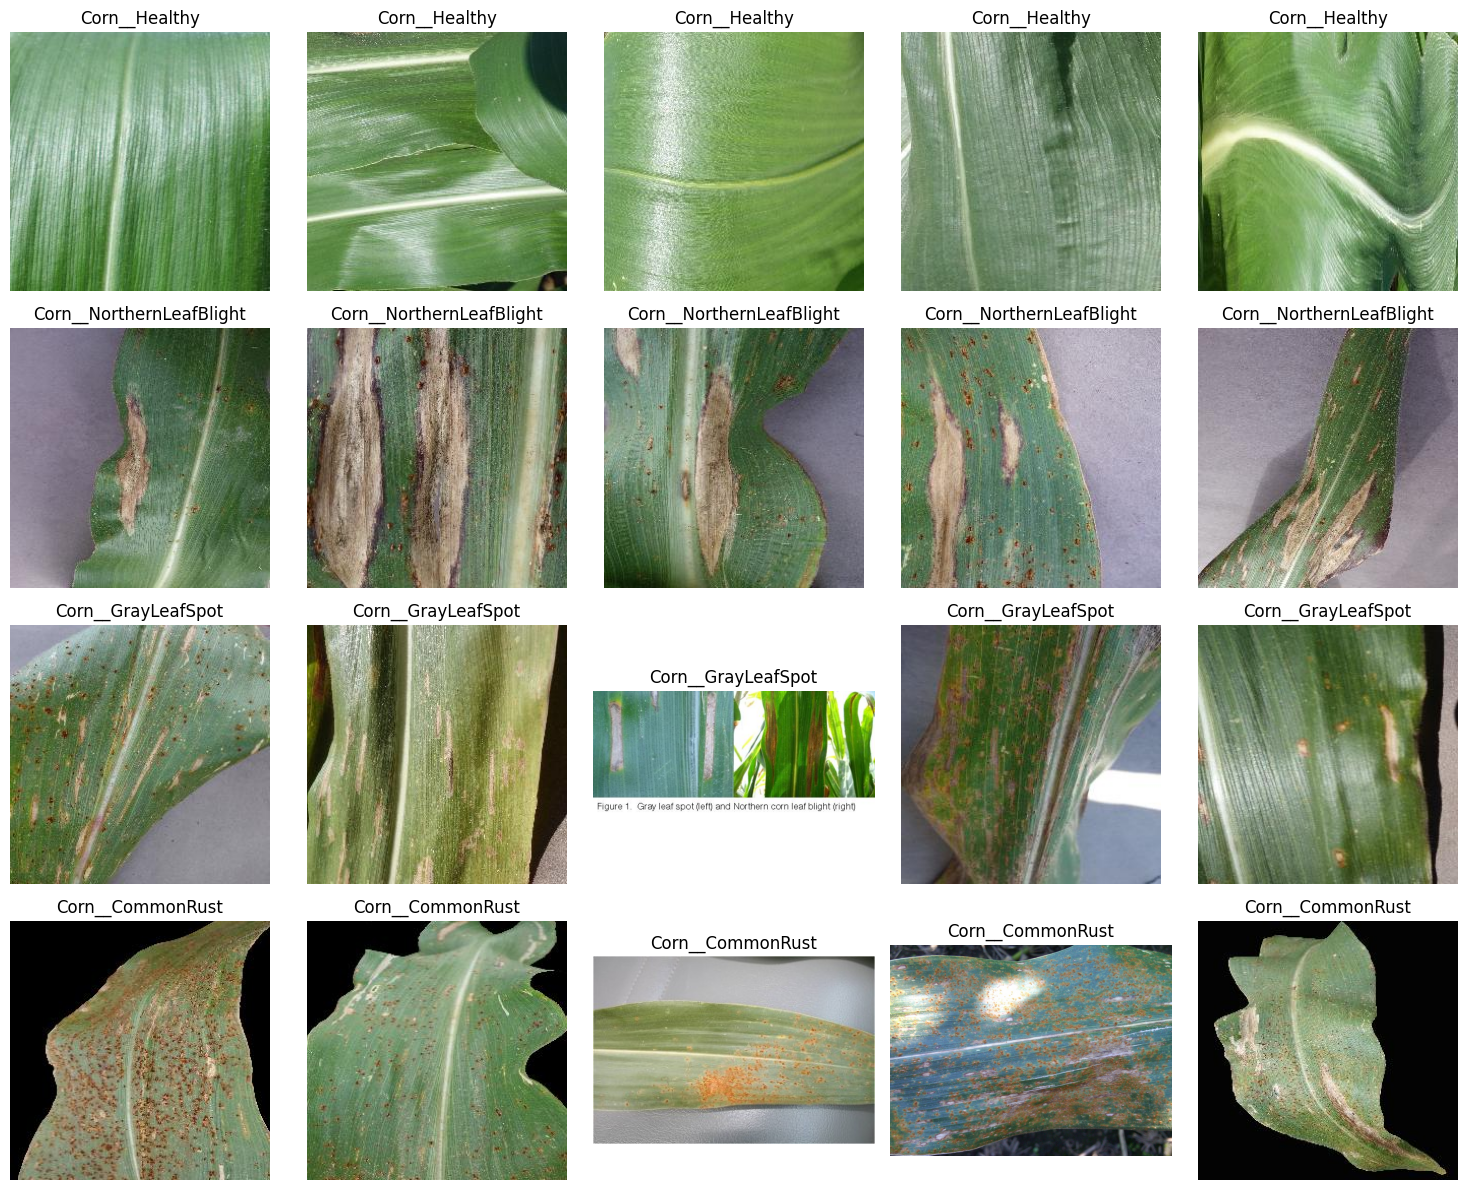

In [8]:


# Path ke dataset klasifikasi
path = "dataset_all" # Changed from "dataset_cls"
path_sub = os.path.join(path)

# Simpan list gambar per class
corn_image = {}

for class_name in os.listdir(path_sub):
    class_path = os.path.join(path_sub, class_name)
    if os.path.isdir(class_path):
        corn_image[class_name] = os.listdir(class_path)

# Buat subplot (jumlah class x 5 gambar)
fig, axs = plt.subplots(len(corn_image.keys()), 5, figsize=(15, 12))

# Loop tiap class
for i, class_name in enumerate(corn_image.keys()):
    images = np.random.choice(corn_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("RGB")  # pakai RGB (lebih cocok untuk CNN)

        axs[i, j].imshow(img)
        axs[i, j].set_title(class_name)
        axs[i, j].axis("off")

plt.tight_layout()
plt.show()

In [9]:
classes = os.listdir(path)

print("Classes:", classes)

Classes: ['Corn__Healthy', 'Corn__NorthernLeafBlight', 'Corn__GrayLeafSpot', 'Corn__CommonRust']


                          count
Corn__CommonRust           1307
Corn__Healthy              1157
Corn__GrayLeafSpot         1000
Corn__NorthernLeafBlight    983


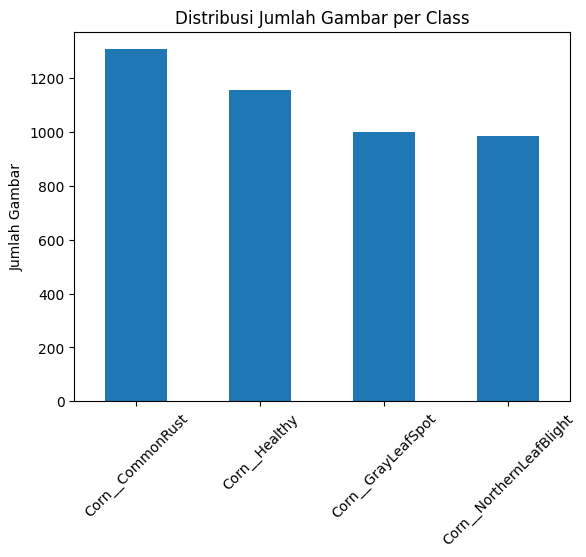

In [10]:
class_counts = {}

for cls in classes:
    cls_path = os.path.join(path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
df_counts = df_counts.sort_values(by='count', ascending=False)

print(df_counts)
df_counts.plot(kind='bar', legend=False)
plt.title("Distribusi Jumlah Gambar per Class")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.show()

In [11]:
widths = []
heights = []

for cls in classes:
    cls_path = os.path.join(path, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Rata-rata Width:", np.mean(widths))
print("Rata-rata Height:", np.mean(heights))

Rata-rata Width: 280.3714863953227
Rata-rata Height: 273.65032606251407


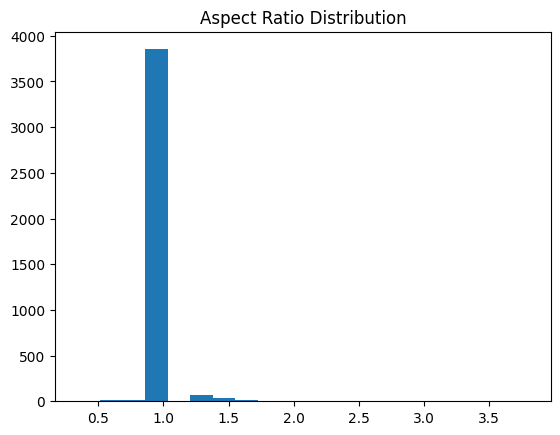

In [ ]:
ratios = [w/h for w, h in zip(widths, heights)]

plt.hist(ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.show()

## Pre Processing

In [ ]:


IMG_SIZE = (224, 224)

def resize(img):
    return tf.image.resize(img, IMG_SIZE)

def rotate(img):
    img = resize(img)
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    return tf.image.rot90(img, k)

def flip(img):
    img = resize(img)
    return tf.image.random_flip_left_right(img)

def brightness(img):
    img = resize(img)
    return tf.image.random_brightness(img, max_delta=0.3)

def contrast(img):
    img = resize(img)
    return tf.image.random_contrast(img, 0.8, 1.2)

def zoom(img):
    img = resize(img)
    scales = list(np.arange(0.8, 1.0, 0.05))
    boxes = np.zeros((len(scales), 4))

    for i, scale in enumerate(scales):
        x1 = y1 = 0.5 - (scale / 2)
        x2 = y2 = 0.5 + (scale / 2)
        boxes[i] = [y1, x1, y2, x2]

    def random_crop(img):
        crops = tf.image.crop_and_resize([img], boxes=boxes,
                                         box_indices=np.zeros(len(scales)),
                                         crop_size=IMG_SIZE)
        return crops[tf.random.uniform([], 0, len(scales), dtype=tf.int32)]

    return random_crop(img)

In [11]:
transformations = [
    rotate,
    flip,
    brightness,
    contrast,
    zoom
]

def apply_random_transforms(img):
    num_transforms = tf.random.uniform([], 1, len(transformations), dtype=tf.int32)

    for _ in range(num_transforms):
        func = transformations[tf.random.uniform([], 0, len(transformations), dtype=tf.int32)]
        img = func(img)

    return img

In [ ]:


INPUT_DIR = "dataset_all/Corn__GrayLeafSpot"

images = os.listdir(INPUT_DIR)

target_size = 1000
current_size = len(images)

to_generate = target_size - current_size

print(f"Current: {current_size}, Target: {target_size}, Generate: {to_generate}")

i = 0

while i < to_generate:
    img_name = np.random.choice(images)
    path = os.path.join(INPUT_DIR, img_name)

    try:
        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 🔥 resize dulu (konsisten)
        img = cv2.resize(img, (224, 224))

        img = tf.convert_to_tensor(img, dtype=tf.float32)

        # 🔥 augment
        aug_img = apply_random_transforms(img)

        aug_img = tf.clip_by_value(aug_img, 0, 255)
        aug_img = tf.cast(aug_img, tf.uint8).numpy()

        # 🔥 nama file unik (biar tidak overwrite)
        new_name = f"aug_{i}_{np.random.randint(10000)}.jpg"
        save_path = os.path.join(INPUT_DIR, new_name)

        cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

        i += 1

    except Exception as e:
        print("Error:", path, e)

print("Augmentasi selesai ✅")

Current: 580, Target: 1000, Generate: 420
Augmentasi selesai ✅


In [13]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= '/content/dataset_all'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)


# Memasukan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapih
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
Corn__CommonRust,1307
Corn__GrayLeafSpot,1000
Corn__Healthy,1157
Corn__NorthernLeafBlight,983


In [ ]:


mypath = "dataset_all"
IMG_SIZE = (224, 224)

file_name = []
labels = []
full_path = []

# 🔁 ambil semua path & label
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# 📊 dataframe
df = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

print(df.groupby(['labels']).size())

labels
Corn__CommonRust            1307
Corn__GrayLeafSpot          1000
Corn__Healthy               1157
Corn__NorthernLeafBlight     983
dtype: int64


In [15]:
label_to_idx = {label: idx for idx, label in enumerate(df['labels'].unique())}
df['label_idx'] = df['labels'].map(label_to_idx)

print(label_to_idx)

{'Corn__Healthy': 0, 'Corn__NorthernLeafBlight': 1, 'Corn__GrayLeafSpot': 2, 'Corn__CommonRust': 3}


In [16]:
# split train vs temp (val+test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['labels'],
    random_state=42
)

# split temp jadi val & test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['labels'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 3112
Val: 667
Test: 668


In [ ]:


OUTPUT_DIR = "dataset"

def process_and_save(dataframe, split_name):
    for i in tqdm(range(len(dataframe)), desc=split_name):
        path = dataframe.iloc[i]['path']
        label = dataframe.iloc[i]['labels']
        file_name = dataframe.iloc[i]['file_name']

        # folder tujuan
        save_dir = os.path.join(OUTPUT_DIR, split_name, label)
        os.makedirs(save_dir, exist_ok=True)

        save_path = os.path.join(save_dir, file_name)

        try:
            img = cv2.imread(path)

            if img is None:
                continue

            # resize
            img = cv2.resize(img, IMG_SIZE)

            # simpan
            cv2.imwrite(save_path, img)

        except Exception as e:
            print("Error:", path, e)

In [18]:
process_and_save(train_df, "train")
process_and_save(val_df, "val")
process_and_save(test_df, "test")

test: 100%|██████████| 668/668 [00:01<00:00, 634.54it/s]


## Image Generator

In [19]:

import os

TRAIN_DIR = "/content/dataset/train"
VAL_DIR = "/content/dataset/val"
TEST_DIR = "/content/dataset/test"

def count_images_per_class(base_dir, split_name):
    print(f"\n📂 {split_name.upper()} SET")

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)

        if os.path.isdir(class_path):
            total = len(os.listdir(class_path))
            print(f"{class_name}: {total} images")

# tampilkan semua
count_images_per_class(TRAIN_DIR, "train")
count_images_per_class(VAL_DIR, "val")
count_images_per_class(TEST_DIR, "test")


📂 TRAIN SET
Corn__Healthy: 810 images
Corn__NorthernLeafBlight: 688 images
Corn__GrayLeafSpot: 700 images
Corn__CommonRust: 914 images

📂 VAL SET
Corn__Healthy: 173 images
Corn__NorthernLeafBlight: 148 images
Corn__GrayLeafSpot: 150 images
Corn__CommonRust: 196 images

📂 TEST SET
Corn__Healthy: 174 images
Corn__NorthernLeafBlight: 147 images
Corn__GrayLeafSpot: 150 images
Corn__CommonRust: 197 images


In [20]:
train_datagen=ImageDataGenerator(
    rescale=1./255,)
test_datagen=ImageDataGenerator(
    rescale=1./255,)
val_datagen=ImageDataGenerator(
    rescale=1./255,)

In [21]:

BATCH_SIZE = 32
train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False  # penting untuk evaluasi
)

Found 3112 images belonging to 4 classes.
Found 667 images belonging to 4 classes.
Found 668 images belonging to 4 classes.


## Build Model

In [23]:

IMG_SIZE = (224, 224)
NUM_CLASSES = 4

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
optimizer = Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:


callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.7609 - loss: 4.9546 - val_accuracy: 0.3808 - val_loss: 5.2920 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7690 - loss: 1.0934 - val_accuracy: 0.4348 - val_loss: 7.0126 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.7985 - loss: 0.5662 - val_accuracy: 0.6177 - val_loss: 2.2461 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8098 - loss: 0.4993 - val_accuracy: 0.6927 - val_loss: 1.1624 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8368 - loss: 0.5229 - val_accuracy: 0.8321 - val_loss: 1.1998 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8368 - loss: 0.4247 - val_accuracy: 0.6462 - val_loss: 1.4446 - learning_rate: 0.0010
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8319 - loss: 0.3928 - val_

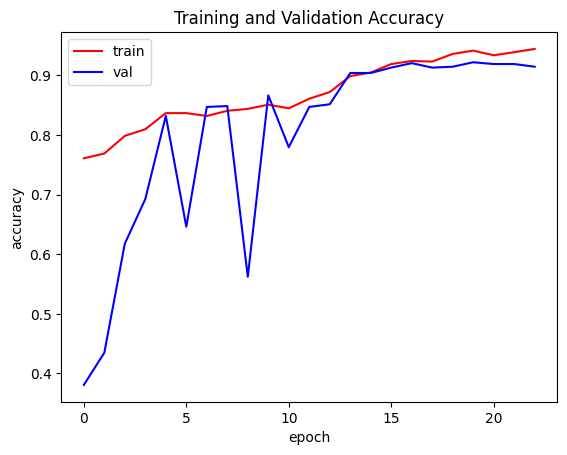

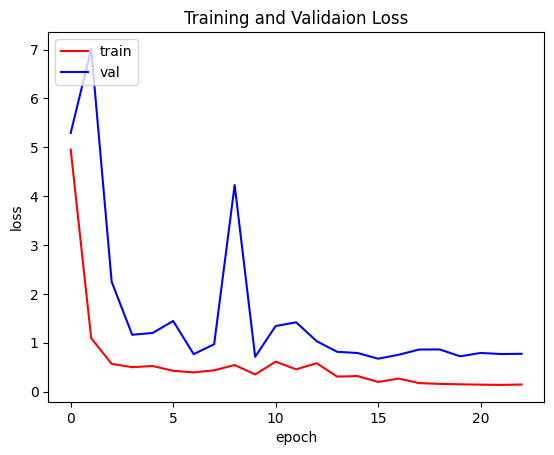

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [29]:
model2= Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
optimizer = Adam(learning_rate=1e-3)

model2.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
callbacks2 = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),
    ModelCheckpoint('best_model.h5', save_best_only=True,monitor='val_accuracy',mode=max)
]

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:138: UserWarning: ModelCheckpoint mode '<built-in function max>' is unknown, fallback to auto mode.
  super().__init__(monitor, mode, initial_value_threshold)


In [34]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,804 (37.49 MB)

 Trainable params: 9,827,844 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [35]:
history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks2
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6976 - loss: 4.8157

98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.7596 - loss: 2.9043 - val_accuracy: 0.2609 - val_loss: 7.0595 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8340 - loss: 0.7556

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8419 - loss: 0.6719 - val_accuracy: 0.3478 - val_loss: 12.5771 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8845 - loss: 0.3397

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8785 - loss: 0.3622 - val_accuracy: 0.4768 - val_loss: 5.0458 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8948 - loss: 0.3624

98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8782 - loss: 0.4147 - val_accuracy: 0.5652 - val_loss: 4.2760 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8808 - loss: 0.4006

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9473 - loss: 0.2700 - val_accuracy: 0.9130 - val_loss: 0.5145 - learning_rate: 3.0000e-04
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9662 - loss: 0.0903

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9656 - loss: 0.0923 - val_accuracy: 0.9280 - val_loss: 0.3272 - learning_rate: 3.0000e-04
Epoch 13/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9659 - loss: 0.0827
Epoch 13: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9695 - loss: 0.0787 - val_accuracy: 0.9250 - val_loss: 0.2856 - learning_rate: 3.0000e-04
Epoch 14/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9693 - loss: 0.0665

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9711 - loss: 0.0707 - val_accuracy: 0.9310 - val_loss: 0.2788 - learning_rate: 9.0000e-05
Epoch 15/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9725 - loss: 0.0599

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9730 - loss: 0.0680 - val_accuracy: 0.9340 - val_loss: 0.2683 - learning_rate: 9.0000e-05
Epoch 16/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9785 - loss: 0.0997 - val_accuracy: 0.9325 - val_loss: 0.2783 - learning_rate: 9.0000e-05
Epoch 17/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9791 - loss: 0.0553 - val_accuracy: 0.9295 - val_loss: 0.2744 - learning_rate: 9.0000e-05
Epoch 18/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9835 - loss: 0.0509
Epoch 18: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9826 - loss: 0.0493 - val_accuracy: 0.9265 - val_loss: 0.3388 - learning_rate: 9.0000e-05
Epoch 19/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9852 - loss: 0.0423 - val_accuracy: 0.9310 - val_loss: 0.3017 - learning_rate: 2.7000e-05
Epoch 20/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9846 - loss: 0.

98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9871 - loss: 0.0347 - val_accuracy: 0.9355 - val_loss: 0.2845 - learning_rate: 2.7000e-05
Epoch 22/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9855 - loss: 0.0430 - val_accuracy: 0.9355 - val_loss: 0.2843 - learning_rate: 8.1000e-06


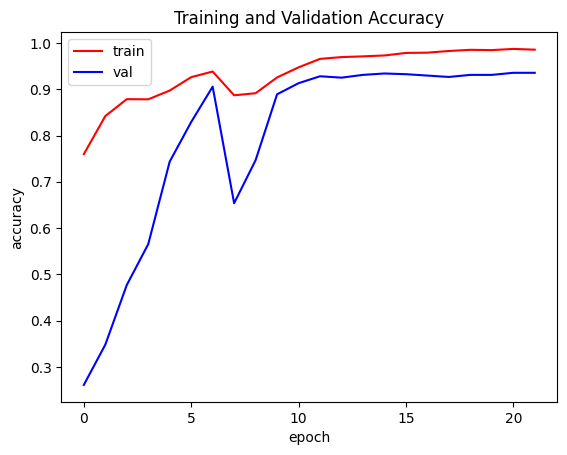

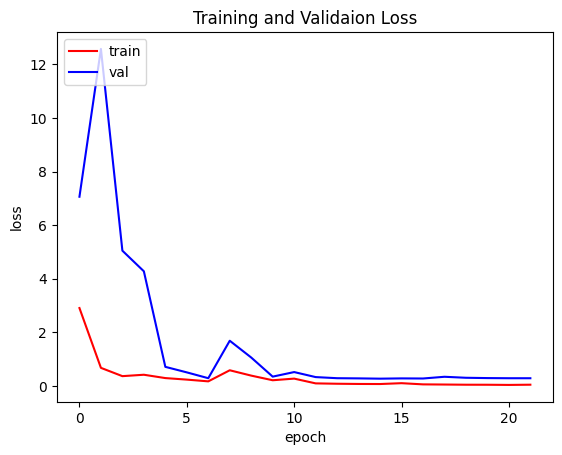

In [36]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [37]:
print(f"accuracy_train {acc[-1]:.4f}")
print(f"accuracy_validasi {val_acc[-1]:.4f}")

accuracy_train 0.9855
accuracy_validasi 0.9355


In [38]:
test_loss, test_acc = model2.evaluate(test_data)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.9207 - loss: 0.3145


In [39]:


y_pred = model2.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))
print(confusion_matrix(y_true, y_pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
                          precision    recall  f1-score   support

        Corn__CommonRust       0.97      0.92      0.95       197
      Corn__GrayLeafSpot       0.82      0.85      0.84       150
           Corn__Healthy       0.99      1.00      1.00       174
Corn__NorthernLeafBlight       0.88      0.89      0.89       147

                accuracy                           0.92       668
               macro avg       0.92      0.92      0.92       668
            weighted avg       0.92      0.92      0.92       668

[[182  12   1   2]
 [  6 128   0  16]
 [  0   0 174   0]
 [  0  16   0 131]]


## Save model

In [41]:
best_model = tf.keras.models.load_model('best_model.h5')

# Export ke SavedModel format (folder)
best_model.export('/content/saved_model')

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139220380902288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380897872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380905360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380905552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380904976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380902672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380904592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380903632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380905168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380907472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220380

In [44]:
from google.colab import files
shutil.make_archive('/content/saved_model', 'zip', '/content/saved_model')
# Download the compressed file
files.download('/content/saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_saved_model("/content/saved_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)
def save_labels(class_indices, filename='labels.txt'):
    # Urutkan berdasarkan index
    labels = sorted(class_indices, key=class_indices.get)

    with open(filename, 'w') as f:
        for label in labels:
            f.write(label + '\n')

# pakai ini
save_labels(train_data.class_indices)

In [45]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

In [1]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  /content/saved_model \
  content/tfjs_model

2026-05-06 00:30:35.193843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778027435.319699   42290 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778027435.332093   42290 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778027435.377608   42290 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778027435.379993   42290 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778027435.380015   42290 computation_placer.cc:177] computation placer alr

## Intrepetasi model

In [19]:
import cv2
import numpy as np

MG_SIZE = (224, 224)

# 🔹 Path gambar
img_path = "/content/dataset_all/Corn__Healthy/pv_CNHE_image (100).jpg"

# 🔹 Load & preprocessing
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # untuk plot

img_resized = cv2.resize(img, IMG_SIZE)
img_resized = img_resized / 255.0
img_resized = np.expand_dims(img_resized, axis=0).astype(np.float32)

In [20]:
from tensorflow.keras.models import load_model
import tensorflow as tf
interpreter = tf.lite.Interpreter(model_path="/content/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]['index'], img_resized)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
pred_class = np.argmax(output)
print("Prediction:", np.argmax(output))

Prediction: 2


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Raw Prediction: [[0. 0. 1. 0.]]
Predicted Index: 2
Predicted Label: Corn__Healthy


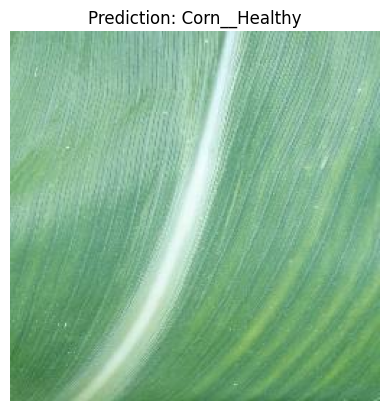

In [21]:
from matplotlib import pyplot as plt
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
labels = [
    "Corn__CommonRust",
    "Corn__GrayLeafSpot",
    "Corn__Healthy",
    "Corn__NorthernLeafBlight"
]


pred_label = labels[pred_class]

print("Raw Prediction:", output)
print("Predicted Index:", pred_class)
print("Predicted Label:", pred_label)

# 🔹 Plot hasil (INI BUKTI INFERENCE)
plt.imshow(img_rgb)
plt.title(f"Prediction: {pred_label}")
plt.axis("off")
plt.show()